# 配套实践 03-02：训练 CNN 定位红色杯子

本练习对应基础篇第 03 章。我们生成带蓝色干扰物的人工桌面图像，让一个小型 PyTorch CNN 预测红色目标中心。依赖：PyTorch、NumPy、Matplotlib；Google Colab 的 CPU 即可运行。

<a href="https://qi-robotics.github.io/robot-world-model-tutorial/basics/03-vision-encoding/" target="_blank">返回课程正文</a>

In [1]:
import numpy as np  # 生成可重复的人工图像数据
import matplotlib.pyplot as plt  # 绘制样本、损失和预测结果
import torch  # 构造张量并执行自动求导
from torch import nn  # 使用卷积层、池化层和损失函数
torch.manual_seed(7)  # 固定网络初始化和训练随机性
np.random.seed(7)  # 固定人工数据的随机性
torch.set_num_threads(2)  # 限制教学实验的 CPU 线程数量

## 1. 生成训练集与未见背景验证集

红色圆形是目标，蓝色方块是干扰物。验证集使用不同背景颜色，帮助检查网络是否只记住训练背景。标签是目标中心除以 63 后得到的归一化坐标。

In [2]:
def make_dataset(sample_count, background_rgb, seed):  # 生成一组人工桌面视觉样本
    rng = np.random.default_rng(seed)  # 为当前数据划分创建独立随机数生成器
    images = np.empty((sample_count, 64, 64, 3), dtype=np.float32)  # 按 HWC 保存待生成图像
    targets = np.empty((sample_count, 2), dtype=np.float32)  # 保存归一化目标中心坐标
    grid_v, grid_u = np.mgrid[0:64, 0:64]  # 为圆形掩码准备像素坐标网格
    for index in range(sample_count):  # 逐个生成独立桌面场景
        image = np.ones((64, 64, 3), dtype=np.float32) * np.asarray(background_rgb, dtype=np.float32)  # 填充当前背景颜色
        center_u = int(rng.integers(9, 55))  # 随机选择红色目标的水平中心
        center_v = int(rng.integers(9, 55))  # 随机选择红色目标的垂直中心
        radius = int(rng.integers(4, 8))  # 随机改变目标大小以避免固定模板
        target_mask = (grid_u - center_u) ** 2 + (grid_v - center_v) ** 2 <= radius ** 2  # 找出圆形目标像素
        image[target_mask] = np.array([0.95, 0.08, 0.08], dtype=np.float32)  # 把目标区域涂成红色
        box_u = int(rng.integers(3, 53))  # 随机选择蓝色干扰物左上角列
        box_v = int(rng.integers(3, 53))  # 随机选择蓝色干扰物左上角行
        image[box_v:box_v + 8, box_u:box_u + 8] = np.array([0.08, 0.20, 0.90], dtype=np.float32)  # 加入蓝色方形干扰物
        images[index] = image  # 保存当前 RGB 图像
        targets[index] = np.array([center_u / 63.0, center_v / 63.0], dtype=np.float32)  # 保存归一化中心坐标
    image_tensor = torch.from_numpy(images).permute(0, 3, 1, 2)  # 把 BHWC 改为 PyTorch 使用的 BCHW
    target_tensor = torch.from_numpy(targets)  # 把二维位置标签转换为张量
    return image_tensor, target_tensor  # 返回图像和一一对应的位置标签
train_images, train_targets = make_dataset(640, (0.72, 0.68, 0.58), seed=10)  # 生成训练背景上的样本
valid_images, valid_targets = make_dataset(160, (0.48, 0.57, 0.54), seed=20)  # 生成不同背景的验证样本
assert train_images.shape == (640, 3, 64, 64)  # 检查训练图像的 batch 和通道顺序
assert train_targets.min() >= 0.0 and train_targets.max() <= 1.0  # 检查标签位于约定范围

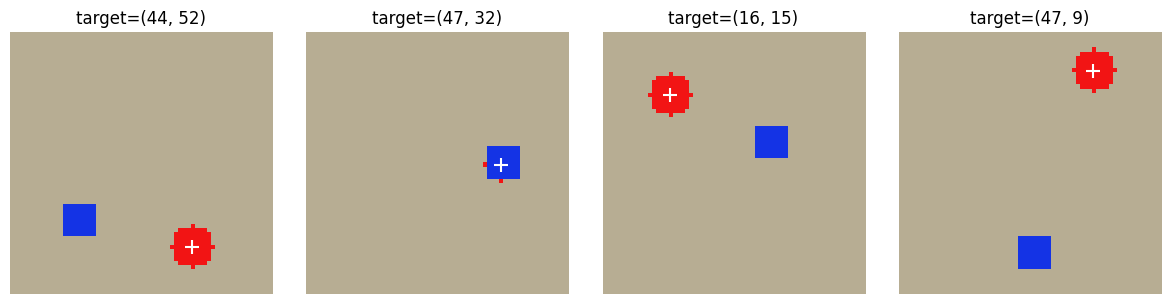

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))  # 创建四个训练样本的画布
for index, axis in enumerate(axes):  # 逐个显示样本和标签
    image = train_images[index].permute(1, 2, 0).numpy()  # 把 CHW 转回绘图使用的 HWC
    target_pixel = train_targets[index].numpy() * 63.0  # 把归一化坐标还原为像素位置
    axis.imshow(image)  # 显示当前人工桌面图像
    axis.scatter(target_pixel[0], target_pixel[1], marker="+", s=90, color="white")  # 标出真实目标中心
    axis.set_title(f"target=({target_pixel[0]:.0f}, {target_pixel[1]:.0f})")  # 显示标签像素值
    axis.axis("off")  # 隐藏不必要的坐标刻度
plt.tight_layout()  # 避免标题互相遮挡
plt.show()  # 显示人工训练样本

## 2. 定义空间特征与位置读出头

编码器把 64×64 图像下采样到 16×16 特征图。读出头保留空间网格并预测两个归一化坐标。

In [4]:
class TinyPositionCNN(nn.Module):  # 定义用于位置回归的小型卷积网络
    def __init__(self):  # 创建编码器和任务读出头
        super().__init__()  # 初始化 PyTorch 模块基类
        self.encoder = nn.Sequential(nn.Conv2d(3, 12, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), nn.Conv2d(12, 24, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))  # 提取十六乘十六空间特征
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(24 * 16 * 16, 48), nn.ReLU(), nn.Linear(48, 2), nn.Sigmoid())  # 把空间特征读成归一化二维位置
    def forward(self, image):  # 定义图像到位置的前向计算
        feature_map = self.encoder(image)  # 保留带空间索引的卷积特征图
        position = self.head(feature_map)  # 预测目标中心的两个归一化坐标
        return position, feature_map  # 同时返回任务输出和视觉表示
model = TinyPositionCNN()  # 实例化一个待训练网络
probe_position, probe_feature = model(train_images[:4])  # 用四张图检查网络接口
assert probe_position.shape == (4, 2)  # 检查位置输出维度
assert probe_feature.shape == (4, 24, 16, 16)  # 检查空间特征图维度

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)  # 使用 Adam 更新全部网络参数
loss_function = nn.MSELoss()  # 用均方误差比较二维预测和真实标签
batch_size = 64  # 每次参数更新使用六十四张图像
history = []  # 保存每轮平均训练损失
for epoch in range(18):  # 多次遍历训练数据以逐步修正参数
    permutation = torch.randperm(len(train_images))  # 每轮随机打乱样本顺序
    epoch_losses = []  # 保存当前轮每个 batch 的损失
    model.train()  # 切换到训练模式
    for start in range(0, len(train_images), batch_size):  # 按 batch 读取训练样本
        indices = permutation[start:start + batch_size]  # 取出当前 batch 的样本索引
        predictions, _ = model(train_images[indices])  # 前向计算当前 batch 的位置预测
        loss = loss_function(predictions, train_targets[indices])  # 计算归一化坐标误差
        optimizer.zero_grad()  # 清除上一次更新残留的梯度
        loss.backward()  # 从位置损失反向计算全部参数梯度
        optimizer.step()  # 根据梯度更新卷积编码器与读出头
        epoch_losses.append(loss.item())  # 记录当前 batch 的标量损失
    history.append(float(np.mean(epoch_losses)))  # 保存当前 epoch 的平均损失
    if epoch in {0, 5, 11, 17}:  # 只打印几个关键轮次避免输出过长
        print(f"epoch={epoch + 1:02d}, train_mse={history[-1]:.6f}")  # 报告训练进度

epoch=01, train_mse=0.045171
epoch=06, train_mse=0.002851
epoch=12, train_mse=0.001301
epoch=18, train_mse=0.000901


In [6]:
model.eval()  # 切换到稳定的验证模式
with torch.no_grad():  # 验证时关闭梯度记录以减少开销
    valid_predictions, valid_features = model(valid_images)  # 在未见背景上预测目标位置
    valid_mse = loss_function(valid_predictions, valid_targets).item()  # 计算验证集归一化坐标误差
    pixel_errors = torch.linalg.vector_norm((valid_predictions - valid_targets) * 63.0, dim=1)  # 把二维误差换成像素距离
print(f"验证 MSE: {valid_mse:.6f}")  # 输出与训练目标一致的验证损失
print(f"平均像素距离误差: {pixel_errors.mean().item():.2f} px")  # 输出更直观的定位误差
assert torch.isfinite(valid_predictions).all()  # 确认模型没有产生无效数值
assert valid_features.shape == (160, 24, 16, 16)  # 确认验证时仍输出空间特征

验证 MSE: 0.002668
平均像素距离误差: 4.11 px


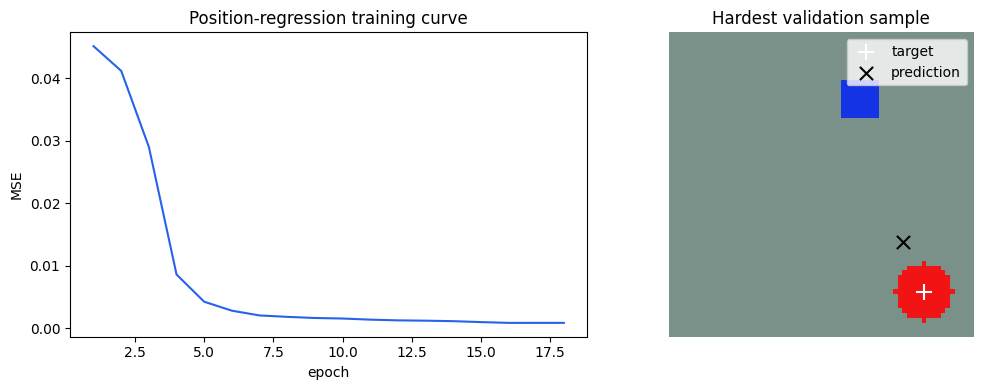

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))  # 同时展示训练曲线和一个定位结果
axes[0].plot(np.arange(1, len(history) + 1), history, color="#2563eb")  # 绘制每轮平均训练损失
axes[0].set_xlabel("epoch")  # 标注训练轮数
axes[0].set_ylabel("MSE")  # 标注训练目标的数值单位
axes[0].set_title("Position-regression training curve")  # 说明左图含义
sample_index = int(torch.argmax(pixel_errors).item())  # 选择验证集中误差最大的样本便于诊断
sample_image = valid_images[sample_index].permute(1, 2, 0).numpy()  # 转换样本为绘图通道顺序
true_pixel = valid_targets[sample_index].numpy() * 63.0  # 还原真实中心的像素坐标
pred_pixel = valid_predictions[sample_index].numpy() * 63.0  # 还原预测中心的像素坐标
axes[1].imshow(sample_image)  # 显示未见背景中的验证图像
axes[1].scatter(true_pixel[0], true_pixel[1], marker="+", s=120, color="white", label="target")  # 标出真实中心
axes[1].scatter(pred_pixel[0], pred_pixel[1], marker="x", s=90, color="black", label="prediction")  # 标出模型预测中心
axes[1].set_title("Hardest validation sample")  # 强调展示的是最大误差案例
axes[1].legend()  # 解释两种位置标记
axes[1].axis("off")  # 隐藏图片坐标刻度
plt.tight_layout()  # 调整两个子图的间距
plt.show()  # 显示训练与验证结果

## 结论与练习

训练损失下降只说明模型越来越符合人工训练数据。验证集更换背景后仍应检查最难案例，而不是只看平均值。尝试删掉 `Flatten + Linear`，改成对特征图直接全局平均后预测位置；思考为什么完全丢弃空间索引后，定位会变得困难。